In [24]:
!pip install wurlitzer
from wurlitzer import sys_pipes_forever

sys_pipes_forever()

In [25]:
#using uproot to write generated event into TTree

!pip install uproot
import uproot

import numpy as np
import pandas as pd



In [26]:
#read event data

file4 = uproot.open("PythiaEventsBatchTest.root")

tree = file4['pdEventTree']

#read branches into Awkward array, then numpy arrays

E_array = tree['E'].array().to_numpy()
px_array = tree['px'].array().to_numpy()
py_array = tree['py'].array().to_numpy()
pz_array = tree['pz'].array().to_numpy()
eta_array = tree['eta'].array().to_numpy()
phi_array = tree['phi'].array().to_numpy()



In [27]:
# using FastJet now:
!pip install fastjet
import fastjet

In [28]:
#Bringing in FastJet's anti-kT, creating PseudoJets from input data
#Can make minor edits to use CA, kT algorithms as well

jetdef = fastjet.JetDefinition(fastjet.cambridge_algorithm, 0.4)

jet_set = [fastjet.PseudoJet(px_array[i], py_array[i], pz_array[i], E_array[i]) for i in range(len(E_array))]



In [29]:
#Clustering

antikTcluster = fastjet.ClusterSequence(jet_set, jetdef)



In [30]:
#looking into output

antikTcluster

<fastjet._swig.ClusterSequence; proxy of <Swig Object of type 'fastjet::ClusterSequence *' at 0x7cee318cc330> >

In [31]:
clustered_jets = antikTcluster.inclusive_jets()

In [32]:
#writing output final jets to data file:

file_out = uproot.recreate("FinalJets_FJ_CA.root")

output_dict = {
    "E": [jet.E() for jet in clustered_jets],
    "px": [jet.px() for jet in clustered_jets],
    "py": [jet.py() for jet in clustered_jets],
    "pz": [jet.pz() for jet in clustered_jets]
}

output_df = pd.DataFrame(output_dict)

file_out.mktree("finalJets", output_df)

file_out["finalJets"]



<WritableTree '/finalJets' at 0x7cee44338b60>

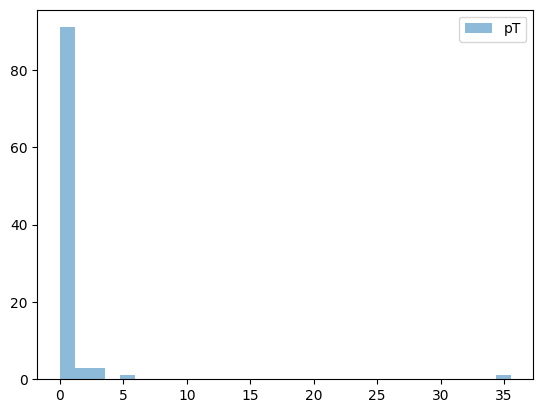

In [33]:
#Plotting distributions from final jets


import matplotlib.pyplot as plt


pT_output = [(jet.px())**2 + (jet.py())**2 for jet in clustered_jets]
pz_output = [jet.pz() for jet in clustered_jets]
E_output = [jet.E() for jet in clustered_jets]

plt.hist(pT_output, bins=30, alpha=0.5, label='pT')
#plt.hist(pz_output, bins=30, alpha=0.5, label='pz')
#plt.hist(E_output, bins=30, alpha=0.5, label='E')
plt.legend()
plt.show()